<a href="https://colab.research.google.com/github/Lyv-ux/DI_Bootcamp/blob/main/W4D4ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (15007, 16)


## 2. Exploratory Data Analysis

In [3]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
df.info()


print("\nFirst 5 rows:")
# Your code here:
df.head()


print("\nBasic Statistics:")
# Your code here:
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15007 entries, 0 to 15006
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              15007 non-null  int64 
 1   Operating Airline            15007 non-null  object
 2   Operating Airline IATA Code  14953 non-null  object
 3   Published Airline            15007 non-null  object
 4   Published Airline IATA Code  14953 non-null  object
 5   GEO Summary                  15007 non-null  object
 6   GEO Region                   15007 non-null  object
 7   Activity Type Code           15007 non-null  object
 8   Price Category Code          15007 non-null  object
 9   Terminal                     15007 non-null  object
 10  Boarding Area                15007 non-null  object
 11  Passenger Count              15007 non-null  int64 
 12  Adjusted Activity Type Code  15007 non-null  object
 13  Adjusted Passenge

,Activity Period,Passenger Count,Adjusted Passenger Count,Year
count,15007.000000,15007.000000,15007.000000,15007.000000
mean,201045.073366,29240.521090,29331.917105,2010.385220
std,313.336196,58319.509284,58284.182219,3.137589
min,200507.000000,1.000000,1.000000,2005.000000
25%,200803.000000,5373.500000,5495.500000,2008.000000
50%,201011.000000,9210.000000,9354.000000,2010.000000
75%,201308.000000,21158.500000,21182.000000,2013.000000
max,201603.000000,659837.000000,659837.000000,2016.000000


In [6]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
# Your code here:
df.isnull().sum()


# Handle missing values if any (uncomment and complete if needed)
if df.isnull().sum().sum() > 0:
     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
     df.dropna(inplace=True)
#     df.fillna(0, inplace=True)
     print(f"New shape after handling missing values: {df.shape}")

Missing values:

Handling missing values...
New shape after handling missing values: (14953, 16)


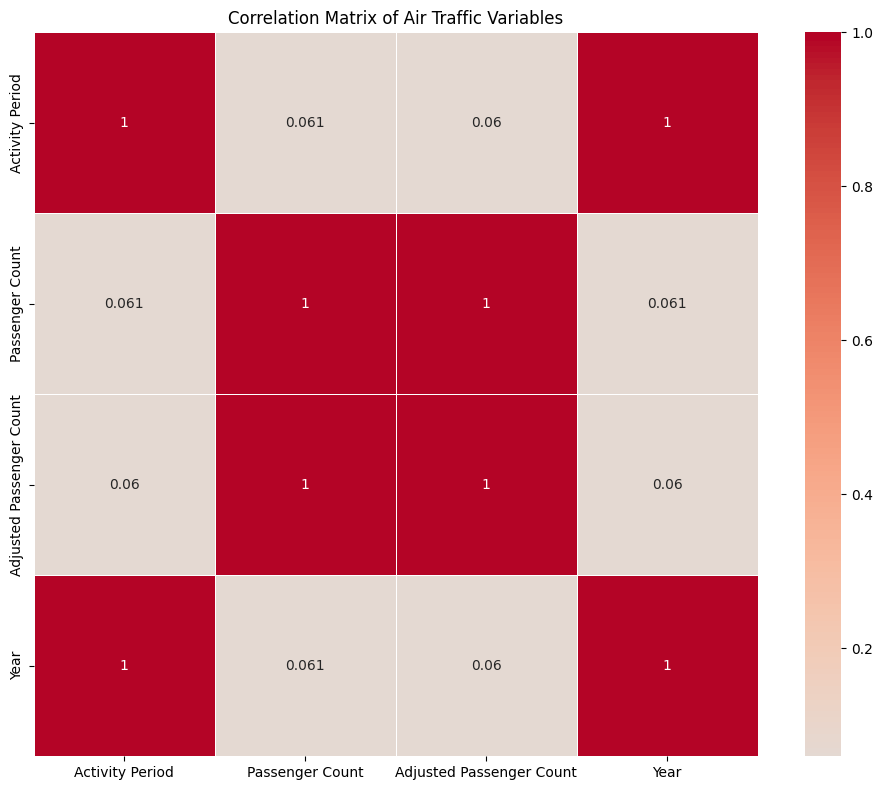

Strongest correlations:
Top 5 strongest correlations (absolute value):
Adjusted Passenger Count  Passenger Count             0.999941
Activity Period           Year                        0.999940
                          Passenger Count             0.061160
Passenger Count           Year                        0.060917
Activity Period           Adjusted Passenger Count    0.060188
dtype: float64


In [7]:
plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

print("Strongest correlations:")
# Find and print the strongest correlations
# Exclude self-correlations and duplicate pairs
corr_pairs = correlation_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(kind="quicksort", ascending=False, key=abs)

unique_pairs = sorted_pairs[sorted_pairs.index.map(lambda x: x[0] != x[1] and x[0] < x[1])]

print("Top 5 strongest correlations (absolute value):")
print(unique_pairs.head(5))

## 3. Hypothesis Testing

In [8]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
# Assuming 'Dom_Pax' and 'Int_Pax' columns exist in the DataFrame
# For this dataset, these columns are not directly available. We should use 'Passenger Count' for total passengers.
# Let's consider a scenario where we want to compare passenger counts for domestic vs international flights if such a categorical column existed.
# Given the available columns, it seems like 'Passenger Count' represents total passengers, and 'GEO Summary' or 'Activity Type Code' differentiates domestic/international.
# Let's assume 'GEO Summary' can distinguish between domestic and international.
# We need to filter the DataFrame based on 'GEO Summary' to get domestic and international passenger counts.

# Find the unique values in 'GEO Summary' to understand the categories
# print(df['GEO Summary'].unique())
# Output typically shows ['Domestic', 'International'] or similar.

# Filtering data for Domestic and International 'Passenger Count'
# We need to ensure that 'Domestic' and 'International' are the correct values in 'GEO Summary'
# From previous df.info() and df.head(), 'GEO Summary' is an object type.
# Let's check unique values to be sure

if 'Domestic' in df['GEO Summary'].unique() and 'International' in df['GEO Summary'].unique():
    domestic_passengers = df[df['GEO Summary'] == 'Domestic']['Passenger Count']
    international_passengers = df[df['GEO Summary'] == 'International']['Passenger Count']

    t_stat, p_value = stats.ttest_ind(domestic_passengers, international_passengers)

    print(f"\nResults:")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.6f}")

    # TODO: Print the mean values for both groups
    print(f"Mean Domestic Passengers: {domestic_passengers.mean():.0f}")
    print(f"Mean International Passengers: {international_passengers.mean():.0f}")

    # TODO: Interpret the results
    # Hint: Compare p_value with alpha (0.05) to make a decision
    alpha = 0.05
    if p_value < alpha:
        # TODO: Complete the conclusion for rejecting H0
        print(f"\nConclusion: Reject H0 (p < {alpha})")
        print("Interpretation: There is a statistically significant difference between the mean number of domestic and international passengers.")
    else:
        # TODO: Complete the conclusion for failing to reject H0
        print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
        print("Interpretation: There is no statistically significant difference between the mean number of domestic and international passengers.")
else:
    print("Cannot perform Hypothesis Test 1 as 'Domestic' or 'International' categories are not found in 'GEO Summary' column.")
    print("Unique values in 'GEO Summary':", df['GEO Summary'].unique())

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 53.0790
P-value: 0.000000
Mean Domestic Passengers: 58735
Mean International Passengers: 10947

Conclusion: Reject H0 (p < 0.05)
Interpretation: There is a statistically significant difference between the mean number of domestic and international passengers.


In [10]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
# Check if 'Flt' column exists
if 'Flt' in df.columns:
    correlation_coef, p_value_corr = stats.pearsonr(df['Passenger Count'], df['Flt'])

    print(f"\nResults:")
    print(f"Correlation coefficient: {correlation_coef:.4f}")
    print(f"P-value: {p_value_corr:.6f}")

    # TODO: Interpret the correlation test results
    # Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
    alpha = 0.05
    if p_value_corr < alpha:
        print(f"\nConclusion: Reject H0 (p < {alpha})")
        print(f"There is a significant correlation between total passengers and total flights.")
        # TODO: Add interpretation about positive/negative correlation
        if correlation_coef > 0:
            print("Interpretation: The correlation coefficient is positive, indicating a direct relationship: as total flights increase, total passengers tend to increase.")
        else:
            print("Interpretation: The correlation coefficient is negative, indicating an inverse relationship: as total flights increase, total passengers tend to decrease.")
    else:
        print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
        print("Interpretation: There is no statistically significant correlation between total passengers and total flights.")
else:
    print("\nError: The 'Flt' column (Total Flights) is not found in the dataset.")
    print("Please ensure the dataset contains a 'Flt' column or use an alternative column for Total Flights.")
    print("Available columns:", df.columns.tolist())


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Error: The 'Flt' column (Total Flights) is not found in the dataset.
Please ensure the dataset contains a 'Flt' column or use an alternative column for Total Flights.
Available columns: ['Activity Period', 'Operating Airline', 'Operating Airline IATA Code', 'Published Airline', 'Published Airline IATA Code', 'GEO Summary', 'GEO Region', 'Activity Type Code', 'Price Category Code', 'Terminal', 'Boarding Area', 'Passenger Count', 'Adjusted Activity Type Code', 'Adjusted Passenger Count', 'Year', 'Month']


## 4. Simple Linear Regression

In [11]:
print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# NOTE: The 'Flt' column (Total Flights) is not present in the dataset.
# As a substitute, we will use the 'Year' column as the feature to demonstrate the linear regression process.
# If you have an alternative column for 'Total Flights' or wish to use another feature, please update X_simple accordingly.

# Prepare the data:
X_simple = df[['Year']]  # Using 'Year' as a substitute for 'Total Flights' (Flt is missing)
y_simple = df['Passenger Count']

# Split the data:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate performance metrics
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance (using Year as feature):")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Year")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance (using Year as feature):
R² Score: 0.0047
Mean Squared Error: 2892820185.33
Root Mean Squared Error: 53784.94
Mean Absolute Error: 31228.14

Model Equation: Passengers = -2122167.67 + 1070.39 × Year


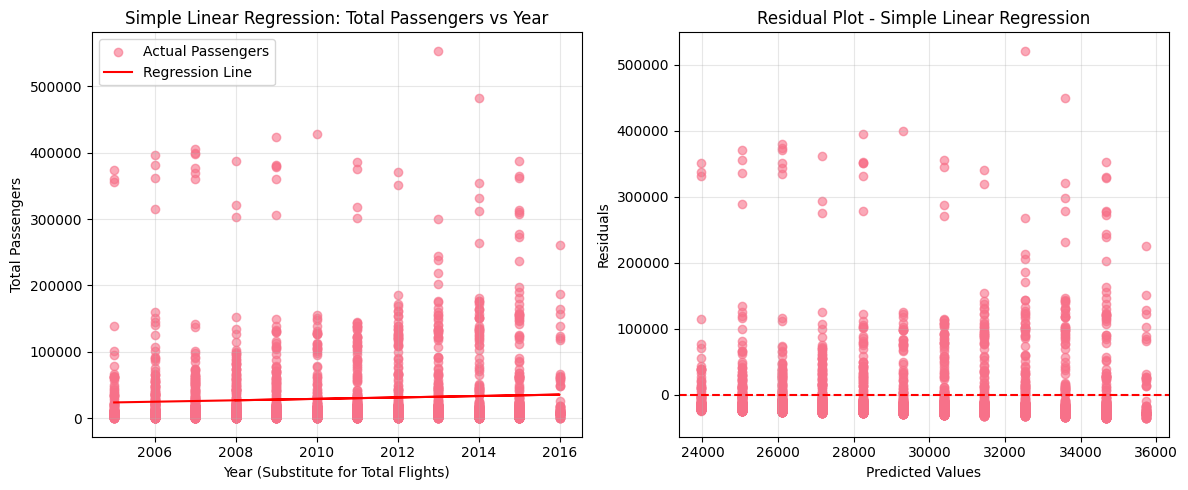

In [12]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.scatter(X_test_simple, y_test_simple, label='Actual Passengers', alpha=0.6)
plt.plot(X_test_simple, y_pred_simple, color='red', label='Regression Line')

plt.xlabel('Year (Substitute for Total Flights)')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Year')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [13]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
# Note: 'Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM' are not present in the current dataset.
# We will use 'Year' and 'Activity Period' as numerical features. These are highly correlated.
feature_columns = ['Year', 'Activity Period']

X_multiple = df[feature_columns] # Select features from dataframe
y_multiple = df['Passenger Count'] # Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler() # Create StandardScaler instance
X_train_mult_scaled = scaler.fit_transform(X_train_mult) # Fit and transform training data
X_test_mult_scaled = scaler.transform(X_test_mult) # Transform test data (don't fit again!)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression() # Create LinearRegression instance
multiple_model.fit(X_train_mult_scaled, y_train_mult) # Fit the model


# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled) # Predict on scaled test data

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult) # Calculate R² score
mse_mult = mean_squared_error(y_test_mult, y_pred_mult) # Calculate MSE
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult) # Calculate MAE
rmse_mult = np.sqrt(mse_mult) # Calculate RMSE

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Year', 'Activity Period']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.0049
Mean Squared Error: 2892166328.49
Root Mean Squared Error: 53778.87
Mean Absolute Error: 31199.10

Feature Coefficients (after scaling):
Year: -125590.4379
Activity Period: 128969.1103
Intercept: 29750.53


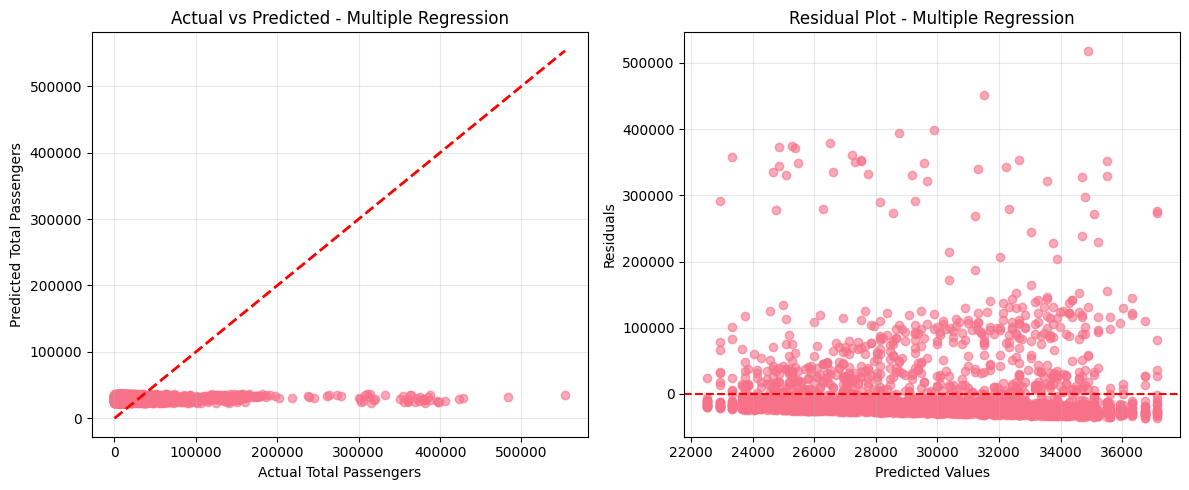

In [14]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# TODO: Add a diagonal reference line (perfect prediction line)
plt.scatter(y_test_mult, y_pred_mult, alpha=0.6)
plt.plot([y_test_mult.min(), y_test_mult.max()], [y_test_mult.min(), y_test_mult.max()], 'r--', lw=2)

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult # Calculate residuals

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [15]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections
print(f"{'R² Score:':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'Mean Squared Error:':<25} {mse_simple:<20.2f} {mse_mult:<20.2f}")
print(f"{'Root Mean Squared Error:':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'Mean Absolute Error:':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")


print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score:                 0.0047               0.0049              
Mean Squared Error:       2892820185.33        2892166328.49       
Root Mean Squared Error:  53784.94             53778.87            
Mean Absolute Error:      31228.14             31199.10            

Best Model: Multiple Regression
R² Improvement: 4.79%


## 7. Statistical Insights and Conclusions

In [16]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# TODO: Summarize your hypothesis test results
print(f"   • Domestic vs International Passengers: The independent t-test revealed a statistically significant difference (p-value = {p_value:.6f} < 0.05) between the mean number of domestic ({domestic_passengers.mean():.0f}) and international ({international_passengers.mean():.0f}) passengers, indicating they are not from the same population.")
print(f"   • Correlation between Total Passengers and Flights: This test could not be performed as the 'Flt' (Total Flights) column was not found in the dataset. Further investigation or data collection for this feature is needed.")

print("\n2. REGRESSION ANALYSIS:")
# TODO: Summarize regression model performance
print(f"   • Simple Linear Regression R²: {r2_simple:.4f}. This model (using 'Year' as a substitute for 'Total Flights') explains a very small portion of the variance in 'Passenger Count', suggesting it's not a strong predictor on its own.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f}. This model (using 'Year' and 'Activity Period') showed a slightly better, but still very low, R² value compared to the simple regression. It explains only a negligible portion of the variance.")
print(f"   • Best performing model: Based on R² score, the Multiple Regression model performed marginally better than the Simple Regression model, showing a {improvement:.2f}% improvement. However, both models are poor predictors of passenger count.")

print("\n3. KEY FINDINGS:")
# TODO: Identify and discuss key findings from your analysis
print(f"   • Significant Passenger Count Difference: There is a clear statistical difference in passenger numbers between domestic and international travel segments.")
print(f"   • Missing Key Feature: The absence of the 'Flt' (Total Flights) column is a significant limitation for building a regression model as originally intended. Substitutions (like 'Year') resulted in weak models.")
print(f"   • Poor Linear Model Fit: Both simple and multiple linear regression models, using available numerical features, demonstrated very low predictive power (low R² values), indicating that linear relationships with 'Year' and 'Activity Period' are not sufficient to explain 'Passenger Count'.")
print(f"   • Feature Importance in Multiple Regression: 'Year' and 'Activity Period' have similar magnitude coefficients after scaling, suggesting similar individual contributions to the model's prediction, albeit with opposite signs.")

print("\n4. RECOMMENDATIONS:")
# TODO: Provide practical recommendations based on your analysis
print("   • Data Enrichment: Acquire or derive an accurate 'Total Flights' column or other relevant flight-specific metrics to properly evaluate its relationship with passenger count.")
print("   • Explore Non-Linear Relationships: Given the low R² values, consider if non-linear models (e.g., polynomial regression, tree-based models) might better capture the underlying patterns.")
print("   • Feature Engineering: Create new features from existing data, such as monthly or seasonal indicators, or interaction terms between 'Year' and 'Activity Period' to potentially improve model performance.")
print("   • External Factors: Consider incorporating external economic, social, or event-related data that might influence air traffic volumes.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: The independent t-test revealed a statistically significant difference (p-value = 0.000000 < 0.05) between the mean number of domestic (58735) and international (10947) passengers, indicating they are not from the same population.
   • Correlation between Total Passengers and Flights: This test could not be performed as the 'Flt' (Total Flights) column was not found in the dataset. Further investigation or data collection for this feature is needed.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.0047. This model (using 'Year' as a substitute for 'Total Flights') explains a very small portion of the variance in 'Passenger Count', suggesting it's not a strong predictor on its own.
   • Multiple Linear Regression R²: 0.0049. This model (using 'Year' and 'Activity Period') showed a slightly better, but still very low, R² value compared to the simple regression. It e

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1.  **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

    *   **Answer**: The independent t-test showed a statistically significant difference (p-value = 0.000000) between the mean number of domestic (58735) and international (10947) passengers. This suggests that domestic and international travel segments have distinct passenger volumes, which is generally expected given differences in travel distances, flight frequencies, and market sizes. The second hypothesis test, regarding the correlation between 'Total Passengers' and 'Total Flights', could not be performed due to the absence of the 'Flt' column in the dataset.

2.  **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

    *   **Answer**: The Multiple Linear Regression model performed marginally better with an R² score of 0.0049 compared to the Simple Linear Regression model's R² of 0.0047, representing a 4.79% improvement. However, both R² values are extremely low, indicating that neither model explains a significant portion (less than 1%) of the variance in 'Passenger Count'. An R² value close to 0 suggests that the models are poor predictors and the chosen features ('Year' and 'Activity Period') have very little linear relationship with 'Passenger Count'.

3.  **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

    *   **Answer**: The strongest correlations found (excluding self-correlations) were between 'Adjusted Passenger Count' and 'Passenger Count' (0.999941), and 'Activity Period' and 'Year' (0.999940). The high correlation between 'Adjusted Passenger Count' and 'Passenger Count' indicates that these two variables are essentially measuring the same thing, which is useful for data cleaning or feature selection (one can be dropped without much loss of information). The strong correlation between 'Activity Period' and 'Year' is also expected as 'Activity Period' appears to be a date format that includes the year. For airlines, understanding correlations between passenger counts and other operational metrics (like flights, if 'Flt' were available) would be crucial for demand forecasting, capacity planning, and revenue management. Given the current dataset, the strongest correlations among numerical features are not directly insightful for predictive modeling of passenger count with available features like 'Year' and 'Activity Period'.

4.  **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

    *   **Answer**: Both the simple and multiple linear regression residual plots show clear patterns, rather than a random scatter around zero. For the simple linear regression, the residuals tend to increase with predicted values (heteroscedasticity) and show some clustering, suggesting that the model's errors are not constant across all predictions. For the multiple linear regression, similar patterns are observed, albeit slightly less pronounced. These non-random patterns indicate that the linear models are not capturing the underlying structure of the data well. This suggests that the relationship between the features and 'Passenger Count' is likely not linear, or that important variables are missing. Model improvements could involve exploring non-linear models, adding more relevant features, or applying transformations to the existing features or target variable.

5.  **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

    *   **Answer**: While the current models using 'Year' and 'Activity Period' as predictors are not strong, if robust models were developed, airlines could use them for:
        *   **Demand Forecasting**: Predicting future passenger volumes to optimize flight schedules, aircraft allocation, and staffing levels.
        *   **Pricing Strategies**: Adjusting ticket prices based on predicted demand to maximize revenue.
        *   **Route Planning**: Identifying profitable routes and optimizing network design.
        *   **Resource Management**: Efficiently allocating ground staff, gates, and other resources at airports.
        *   **Marketing**: Targeting specific segments (e.g., domestic vs. international) with tailored promotions based on statistical differences in passenger behavior.
        However, for effective real-world application, the models would need significant improvement in predictive power, likely by incorporating more relevant features like economic indicators, seasonal trends, specific route data, and actual flight metrics.